#### Reading the development and evaluation datasets 

In [71]:
import pandas as pd

dev_path = "C:\\Users\\alias\\Documents\\Polito\\Data Science Lab\\Project\\DSL_Winter_Project_2025\\development.csv"
eval_path = "C:\\Users\\alias\\Documents\\Polito\\Data Science Lab\\Project\\DSL_Winter_Project_2025\\evaluation.csv"

dataset = pd.read_csv(dev_path)
eval_set = pd.read_csv(eval_path)
dataset.shape

(2933, 20)

#### Droping unrelated attributes from dvevelopment dataset

In [73]:
dataset = dataset.drop(columns=["Id", "sampling_rate", "path"])
Id = eval_set["Id"]

#### Droping unrelated attributes from evaluation dataset

In [74]:
eval_set = eval_set.drop(columns=["Id", "sampling_rate", "path"])

#### Correcting data types and misspelled attribute values in both datasets

In [75]:
dataset["tempo"]=dataset["tempo"].str.strip("[]").astype(float)
eval_set["tempo"]=eval_set["tempo"].str.strip("[]").astype(float)
eval_set['gender'] = eval_set['gender'].replace('female', 'famale')

#### separation of X and y

In [76]:
y= dataset["age"]

In [77]:
X = dataset.drop(columns=["age"])

#### train_test_split (80% training set, 20% test set)

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Resetting index of  X_train and X_test becasue train_test_split assigns points randomly to each sets

In [79]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

#### Standardizing (z-score) the numerical features. Standardizing the X_train with fit_transform function

In [80]:
from sklearn.preprocessing import StandardScaler

zscore = StandardScaler()

columns_to_normalize = ["mean_pitch", "max_pitch", "min_pitch", "jitter"
                        , "shimmer", "energy", "zcr_mean",
                        "spectral_centroid_mean", "tempo", "hnr",
                        "num_words", "num_characters", "num_pauses",
                        "silence_duration"]

X_train[columns_to_normalize] = zscore.fit_transform(X_train[columns_to_normalize])

#### Standardizing the same features in X_test and evaluation set only using transform  

In [81]:
X_test[columns_to_normalize] = zscore.transform(X_test[columns_to_normalize])
eval_set[columns_to_normalize] = zscore.transform(eval_set[columns_to_normalize])

#### Transforming "gender" to numerical feature with one hot encoding in X_train with fit_transform function

In [82]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output= False, dtype=int, handle_unknown="ignore")
genders = ohe.fit_transform(X_train[["gender"]])
encoded_gender = pd.DataFrame(genders, columns = ohe.get_feature_names_out(["gender"]))

#### Concating the encode feature to X_train

In [83]:
X_train_encoded_gender = pd.concat([X_train, encoded_gender], axis=1)

#### Transforming "gender" to numerical feature with one hot encoding in X_test and evauation set with transform function

In [84]:
genders_test = ohe.transform(X_test[["gender"]])
encoded_gender_test = pd.DataFrame(genders_test, columns = ohe.get_feature_names_out(["gender"]))

genders_eval = ohe.transform(eval_set[["gender"]])
encoded_gender_eval = pd.DataFrame(genders_eval, columns = ohe.get_feature_names_out(["gender"]))

#### Concating the encode feature to X_test and evalution set

In [85]:
X_test_encoded_gender = pd.concat([X_test, encoded_gender_test], axis=1)
eval_encoded_gender = pd.concat([eval_set, encoded_gender_eval], axis=1)

#### Doing the same process, transforming "ethnicity" with one hot encoding 

In [86]:
eths = ohe.fit_transform(X_train_encoded_gender[["ethnicity"]])
encoded_eth = pd.DataFrame(eths, columns = ohe.get_feature_names_out(["ethnicity"]))

In [87]:
X_train_encoded_eth = pd.concat([X_train_encoded_gender, encoded_eth], axis=1)

In [88]:
eths_test = ohe.transform(X_test[["ethnicity"]])
encoded_eth_test = pd.DataFrame(eths_test, columns = ohe.get_feature_names_out(["ethnicity"]))

eths_eval = ohe.transform(eval_set[["ethnicity"]])
encoded_eth_eval = pd.DataFrame(eths_eval, columns = ohe.get_feature_names_out(["ethnicity"]))

In [89]:
X_test_encoded_eth = pd.concat([X_test_encoded_gender, encoded_eth_test], axis=1)
eval_encoded_eth = pd.concat([eval_encoded_gender, encoded_eth_eval], axis=1)

#### Droping the orginal featues "gender" and "ethnicity" after encoding from training, test, and evaluation sets. (Only the transformed version is required for training the model) Now we have the final version of our datasets to apply models on.

In [90]:
X_train_final = X_train_encoded_eth.drop(columns=["gender", "ethnicity"])
X_test_final = X_test_encoded_eth.drop(columns=["gender", "ethnicity"])
eval_final = eval_encoded_eth.drop(columns=["gender", "ethnicity"])

#### Visulaizing "tempo" berfore and after normalization

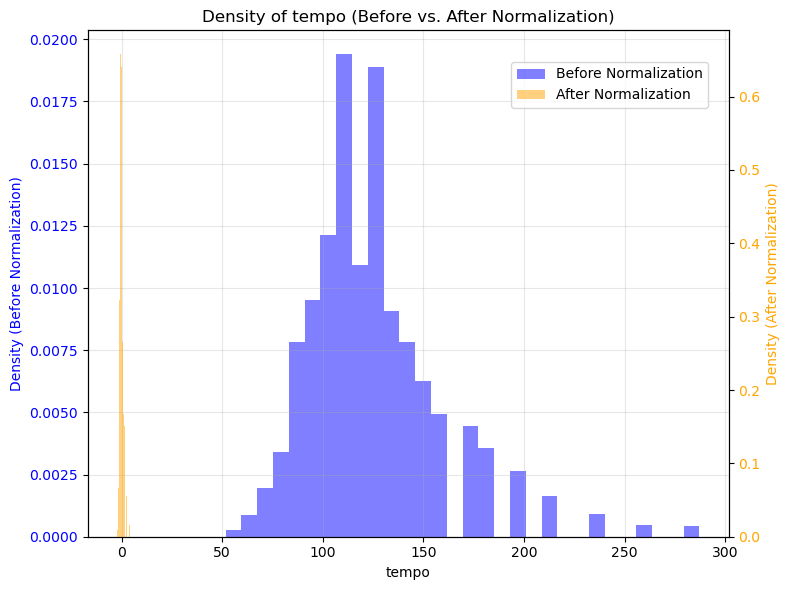

In [91]:
import matplotlib.pyplot as plt

X_train_after_norm = X_train[columns_to_normalize] 

X_train_before_norm = pd.DataFrame(
    zscore.inverse_transform(X_train_after_norm),
    columns=columns_to_normalize
)
fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.hist(X_train_before_norm["tempo"], bins=30, alpha=0.5, label="Before Normalization", density=True, color='blue')
ax1.set_xlabel("tempo")
ax1.set_ylabel("Density (Before Normalization)", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.hist(X_train_after_norm["tempo"], bins=30, alpha=0.5, label="After Normalization", density=True, color='orange')
ax2.set_ylabel("Density (After Normalization)", color='orange')
ax2.tick_params(axis='y', labelcolor='orange')


plt.title("Density of tempo (Before vs. After Normalization)")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
ax1.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("C:\\Users\\alias\\Documents\\Polito\\Data Science Lab\\Project\\DSL_Winter_Project_2025\\tempo.png")
plt.show()

#### Training the model

In [92]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=500, max_depth=30, min_samples_split=3, random_state=42)

In [93]:
model.fit(X_train_final, y_train)

RandomForestRegressor(max_depth=30, min_samples_split=3, n_estimators=500,
                      random_state=42)

In [94]:
y_pred = model.predict(X_test_final)

#### Evaluating the model

In [95]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

9.936220557691227

#### Feature Importance

In [96]:
feature_importances = model.feature_importances_ 
feature_names = X_train_final.columns
importance_df = pd.DataFrame({ 'Feature': feature_names, 'Importance': feature_importances })
print(importance_df)

                  Feature  Importance
0              mean_pitch    0.049139
1               max_pitch    0.046011
2               min_pitch    0.049016
3                  jitter    0.058445
4                 shimmer    0.047937
..                    ...         ...
162  ethnicity_satawalese    0.000044
163         ethnicity_tiv    0.000030
164      ethnicity_ukwani    0.000298
165      ethnicity_urhobo    0.000042
166      ethnicity_yoruba    0.000011

[167 rows x 2 columns]


#### Visualization of the top 15 important features

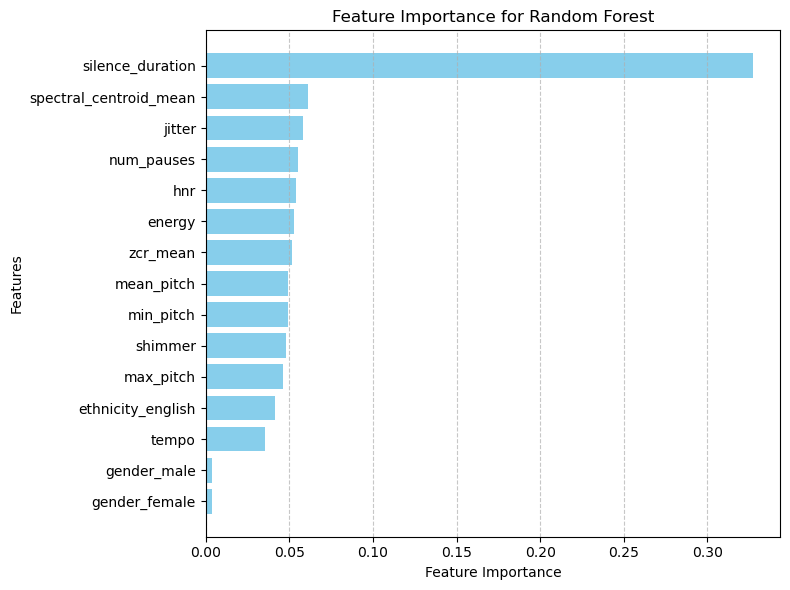

In [97]:
import matplotlib.pyplot as plt

sorted_importance = importance_df.sort_values(by='Importance', ascending=False)
sorted_top_features = sorted_importance.head(15)

plt.figure(figsize=(8, 6))
plt.barh(sorted_top_features['Feature'], sorted_top_features['Importance'], color="skyblue")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance for Random Forest")
plt.gca().invert_yaxis()  
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("C:\\Users\\alias\\Documents\\Polito\\Data Science Lab\\Project\\DSL_Winter_Project_2025\\feature_importance.png")
plt.show()